1. Import Library

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

2. Load Dataset

In [65]:
df = pd.read_csv('../data/KAG_energydata_complete.csv')

print(" Memuat dataset")
print(f"   Jumlah baris  : {df.shape[0]}")
print(f"   Jumlah kolom  : {df.shape[1]}")
df.head()

 Memuat dataset
   Jumlah baris  : 19735
   Jumlah kolom  : 29


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


3. EDA (exploratory data analysis)

In [66]:
#Cek duplikat dan Hapus 

print("=" * 45)
print("CEK DUPLIKAT")
print("=" * 45)

duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat : {duplikat}")

if duplikat > 0:
    df = df.drop_duplicates()
    print(f" Menghapus Duplikat Sisa baris: {df.shape[0]}")
else:
    print(" Tidak ada duplikat  data bersih!")

CEK DUPLIKAT
Jumlah baris duplikat : 0
 Tidak ada duplikat  data bersih!


In [67]:
#Cek Missing Value

print("=" * 45)
print("CEK MISSING VALUE")
print("=" * 45)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct.round(2)
})

print(missing_df[missing_df['Jumlah Missing'] > 0])

if missing.sum() == 0:
    print(" Tidak ada missing value — data lengkap!")
else:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col].fillna(df[col].median(), inplace=True)
                print(f"   Kolom '{col}' diisi dengan median")
    print(" Missing value selesai ditangani")

CEK MISSING VALUE
Empty DataFrame
Columns: [Jumlah Missing, Persentase (%)]
Index: []
 Tidak ada missing value — data lengkap!


In [68]:
#Hapus Kolom Tidak Relevan
print("=" * 45)
print("HAPUS KOLOM TIDAK RELEVAN")
print("=" * 45)

# Kolom date dan random variables tidak berkontribusi ke model
kolom_hapus = ['date', 'rv1', 'rv2']

# Cek dulu apakah kolom ada
kolom_ada = [k for k in kolom_hapus if k in df.columns]
df = df.drop(columns=kolom_ada)

print(f" Kolom dihapus  : {kolom_ada}")
print(f"   Sisa kolom     : {df.shape[1]}")
print(f"   Kolom tersisa  : {list(df.columns)}")

HAPUS KOLOM TIDAK RELEVAN
 Kolom dihapus  : ['date', 'rv1', 'rv2']
   Sisa kolom     : 26
   Kolom tersisa  : ['Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']


CEK OUTLIER PADA TARGET (Appliances)
Batas bawah  : -25.00 Wh
Batas atas   : 175.00 Wh
Jumlah outlier: 2138 baris (10.8%)


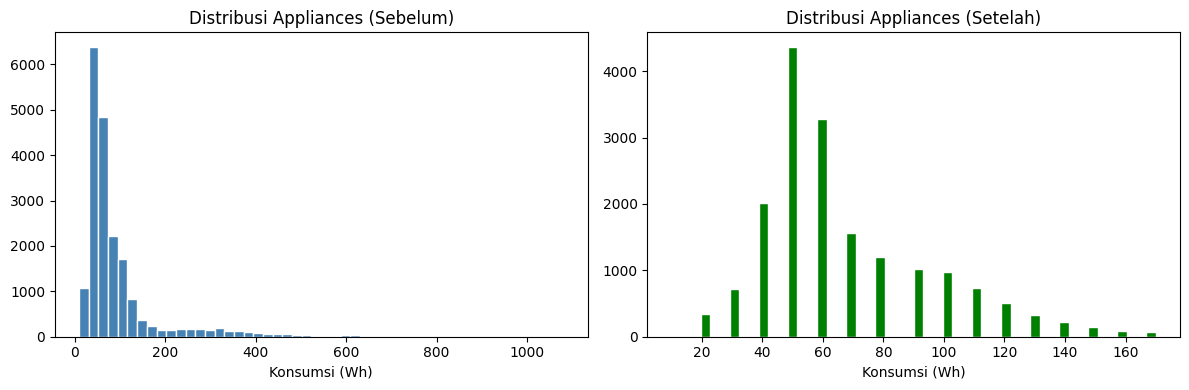


Menangani Outlier sisa baris: 17597


In [69]:
print("=" * 45)
print("CEK OUTLIER PADA TARGET (Appliances)")
print("=" * 45)

# Visualisasi distribusi target sebelum
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['Appliances'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Appliances (Sebelum)')
axes[0].set_xlabel('Konsumsi (Wh)')

# Gunakan IQR untuk deteksi outlier
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas  = Q3 + 1.5 * IQR

outlier = df[(df['Appliances'] < batas_bawah) | (df['Appliances'] > batas_atas)]
print(f"Batas bawah  : {batas_bawah:.2f} Wh")
print(f"Batas atas   : {batas_atas:.2f} Wh")
print(f"Jumlah outlier: {len(outlier)} baris ({len(outlier)/len(df)*100:.1f}%)")

# Hapus outlier ekstrem (di atas batas atas)
df = df[df['Appliances'] <= batas_atas]

axes[1].hist(df['Appliances'], bins=50, color='green', edgecolor='white')
axes[1].set_title('Distribusi Appliances (Setelah)')
axes[1].set_xlabel('Konsumsi (Wh)')

plt.tight_layout()
plt.show()

print(f"\nMenangani Outlier sisa baris: {df.shape[0]}")

In [70]:
print("=" * 45)
print("PISAHKAN FITUR DAN TARGET")
print("=" * 45)

# Target = yang mau diprediksi
y = df['Appliances']

# Fitur = semua kolom kecuali target
X = df.drop(columns=['Appliances'])

print(f" Fitur (X) : {X.shape[1]} kolom")
print(f" Target (y): kolom 'Appliances'")
print(f"\nDaftar fitur:\n{list(X.columns)}")

PISAHKAN FITUR DAN TARGET
 Fitur (X) : 25 kolom
 Target (y): kolom 'Appliances'

Daftar fitur:
['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']


In [71]:
print("=" * 45)
print("NORMALISASI DATA (MinMaxScaler)")
print("=" * 45)

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Jadikan DataFrame lagi supaya mudah dibaca
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Normalisasi selesai! Semua fitur sekarang dalam skala 0–1")
print(f"\nContoh 3 baris pertama setelah normalisasi:")
print(X_scaled_df.head(3).round(4))

NORMALISASI DATA (MinMaxScaler)
Normalisasi selesai! Semua fitur sekarang dalam skala 0–1

Contoh 3 baris pertama setelah normalisasi:
   lights      T1    RH_1      T2    RH_2      T3    RH_3      T4    RH_4  \
0     0.6  0.3294  0.6309  0.2253  0.6840  0.2176  0.7642  0.3514  0.7672   
1     0.6  0.3294  0.6032  0.2253  0.6821  0.2176  0.7670  0.3514  0.7855   
2     0.6  0.3294  0.5911  0.2253  0.6794  0.2176  0.7739  0.3447  0.7811   

       T5  ...      T8    RH_8      T9    RH_9   T_out  Press_mm_hg  RH_out  \
0  0.1755  ...  0.1733  0.6614  0.2230  0.6773  0.3730       0.0963  0.8947   
1  0.1755  ...  0.1733  0.6602  0.2265  0.6785  0.3692       0.0987  0.8947   
2  0.1755  ...  0.1733  0.6556  0.2196  0.6760  0.3655       0.1010  0.8947   

   Windspeed  Visibility  Tdewpoint  
0     0.5000      0.9538     0.5385  
1     0.4762      0.8949     0.5339  
2     0.4524      0.8359     0.5294  

[3 rows x 25 columns]


PEMBAGIAN DATA: TRAIN / VAL / TEST
Total data       : 17597 baris (100%)
Data Training    : 11261 baris (64.0%)
Data Validasi    : 2816 baris (16.0%)
Data Testing     : 3520 baris (20.0%)


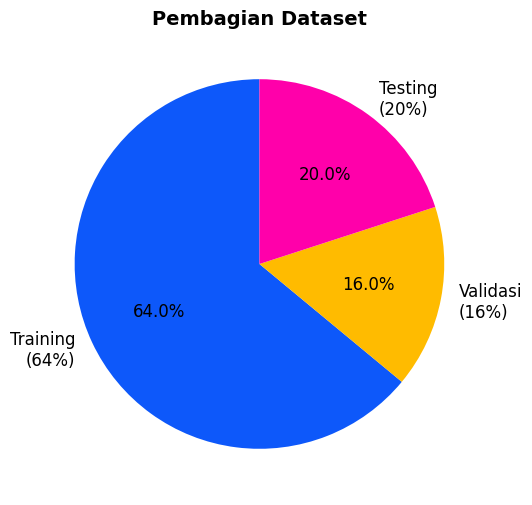

In [72]:
print("=" * 45)
print("PEMBAGIAN DATA: TRAIN / VAL / TEST")
print("=" * 45)

# Memisahkan data menjadi 80% untuk gabungan train dan validation, serta 20% untuk test.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled_df, y,
    test_size=0.20,        # 20% untuk test
    random_state=42
)

# Dari 80% train+val, ambil 20% untuk validasi
# Hasilnya: 64% train, 16% val, 20% test
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.20,        # 20% dari 80% = 16% dari total
    random_state=42
)

total = len(df)
print(f"Total data       : {total} baris (100%)")
print(f"Data Training    : {len(X_train)} baris ({len(X_train)/total*100:.1f}%)")
print(f"Data Validasi    : {len(X_val)} baris ({len(X_val)/total*100:.1f}%)")
print(f"Data Testing     : {len(X_test)} baris ({len(X_test)/total*100:.1f}%)")

# Visualisasi pembagian
labels = ['Training\n(64%)', 'Validasi\n(16%)', 'Testing\n(20%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
colors = ["#0D58FA", "#FFBB00", "#FF00AA"]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 12})
plt.title('Pembagian Dataset', fontsize=14, fontweight='bold')
plt.show()

Menyimpan Semua File

In [73]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../model', exist_ok=True)

# Simpan split data
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_val.to_csv('../data/processed/X_val.csv',   index=False)
X_test.to_csv('../data/processed/X_test.csv',  index=False)

y_train.to_csv('../data/processed/y_train.csv', index=False)
y_val.to_csv('../data/processed/y_val.csv',   index=False)
y_test.to_csv('../data/processed/y_test.csv',  index=False)

# Simpan scaler 
joblib.dump(scaler, '../model/scaler.pkl')

# Simpan nama fitur
with open('../model/feature_names.json', 'w') as f:
    json.dump(list(X.columns), f)

print(" Semua file berhasil disimpan!")
print(" Silahkan cek folder processed")

 Semua file berhasil disimpan!
 Silahkan cek folder processed
